# Polynomial Regression

**Course:** 23CSE301 Machine Learning — Capstone Project
**Review:** Review 1
**Track:** Regression
**Dataset:** `diamonds_sampled.csv`

This notebook implements **one required regression algorithm** while retaining the common dataset audit, EDA, cleaning, feature engineering, leakage-safe preprocessing, evaluation, cross-validation, diagnostics, and result-export structure required for Review 1.

## 0. Environment and rubric coverage

Required packages: `numpy`, `pandas`, `matplotlib`, `scikit-learn`, `joblib`. This notebook avoids `seaborn`, so it does not depend on that optional package being installed.

The notebook covers A1/A2/A3 (audit + EDA + observations), B1/B2/B3 (cleaning + leakage-safe preprocessing + feature engineering), the selected regression algorithm, mandatory R²/RMSE/MAE evaluation, and 5-fold cross-validation. Algorithm-specific tuning is included where applicable.

In [17]:
import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET = "price"
DATA_FILENAME = "diamonds_sampled.csv"
np.random.seed(RANDOM_STATE)

In [18]:
def resolve_file(filename):
    candidates = [
        Path("../data") / filename,
        Path("data") / filename,
        Path("/mnt/data") / filename,
        Path(filename),
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not find {filename}. Checked: {[str(p) for p in candidates]}")

DATA_PATH = resolve_file(DATA_FILENAME)
print("Using dataset:", DATA_PATH.resolve())

Using dataset: C:\Sem-5\ml\jyp_notebook\Reg_review1\diamonds_sampled.csv


In [19]:
class IQRClipper(BaseEstimator, TransformerMixin):
    """Clip numeric values using train-fitted IQR bounds to reduce extreme influence."""
    def __init__(self, factor=1.5):
        self.factor = factor

    def fit(self, X, y=None):
        X_arr = np.asarray(X, dtype=float)
        self.q1_ = np.nanpercentile(X_arr, 25, axis=0)
        self.q3_ = np.nanpercentile(X_arr, 75, axis=0)
        iqr = self.q3_ - self.q1_
        self.lower_ = self.q1_ - self.factor * iqr
        self.upper_ = self.q3_ + self.factor * iqr
        return self

    def transform(self, X):
        X_arr = np.asarray(X, dtype=float)
        return np.clip(X_arr, self.lower_, self.upper_)

## 1. Dataset loading & audit — A1

In [20]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nData types:")
display(df.dtypes.to_frame("dtype"))
print("\nMissing values:")
display(df.isnull().sum().to_frame("missing"))
print("\nDuplicate rows:", df.duplicated().sum())
print("\nTarget summary:")
display(df[TARGET].describe().to_frame("value"))
print("\nTarget unique values:", df[TARGET].nunique())
display(df.head())

Shape: (2100, 11)

Data types:


,dtype
id: 0,int64
carat,float64
cut,str
color,str
clarity,str
depth,float64
table,float64
price,int64
x,float64
y,float64



Missing values:


,missing
id: 0,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0



Duplicate rows: 0

Target summary:


,value
count,2100.000000
mean,3971.387143
std,4124.225067
min,360.000000
25%,926.750000
50%,2324.500000
75%,5357.250000
max,18803.000000



Target unique values: 1623


,id: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1389,0.24,Ideal,G,VVS1,62.1,56.0,559,3.97,4.00,2.47
1,50053,0.58,Very Good,F,VVS2,60.0,57.0,2201,5.44,5.42,3.26
2,41646,0.40,Ideal,E,VVS2,62.1,55.0,1238,4.76,4.74,2.95
3,42378,0.43,Premium,E,VVS2,60.8,57.0,1304,4.92,4.89,2.98
4,17245,1.55,Ideal,E,SI2,62.3,55.0,6901,7.44,7.37,4.61


### A1 observation — student interpretation required

Use the actual audit output above to write a short observation covering the dataset size, feature types, missing values, duplicates, and the target distribution. Keep the wording original to your team.

## 2. Data cleaning — B1

In [21]:
df_clean = df.copy()

# Remove the source-row identifier because it identifies a record rather than a diamond property.
if "id: 0" in df_clean.columns:
    df_clean = df_clean.drop(columns=["id: 0"])

print("Duplicate rows before removal:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Duplicate rows after removal:", df_clean.duplicated().sum())

num_for_outliers = [c for c in df_clean.select_dtypes(include=np.number).columns if c != TARGET]
outlier_rows = []
for c in num_for_outliers:
    q1 = df_clean[c].quantile(0.25)
    q3 = df_clean[c].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = int(((df_clean[c] < lower) | (df_clean[c] > upper)).sum())
    outlier_rows.append({"Feature": c, "IQR Outliers": count})

outlier_df = pd.DataFrame(outlier_rows).sort_values("IQR Outliers", ascending=False)
display(outlier_df)
print("Missing values after duplicate/ID handling:")
display(df_clean.isnull().sum().to_frame("missing"))

Duplicate rows before removal: 1
Duplicate rows after removal: 0


,Feature,IQR Outliers
1,depth,114
0,carat,64
2,table,26
3,x,1
4,y,1
5,z,1


Missing values after duplicate/ID handling:


,missing
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


### B1 justification — student interpretation required

Explain the missing-value strategy, duplicate handling, and why the IQR-screened observations are clipped inside the training pipeline rather than blindly deleting legitimate extreme diamonds. Note that the clipper is fitted only on training data.

## 3. Feature engineering — B3

In [22]:
df_clean["volume"] = df_clean["x"] * df_clean["y"] * df_clean["z"]
print("Created feature: volume = x × y × z")
display(df_clean[["x", "y", "z", "volume", TARGET]].head())

Created feature: volume = x × y × z


,x,y,z,volume,price
0,3.97,4.00,2.47,39.223600,559
1,5.44,5.42,3.26,96.120448,2201
2,4.76,4.74,2.95,66.559080,1238
3,4.92,4.89,2.98,71.695224,1304
4,7.44,7.37,4.61,252.779208,6901


### B3 justification — student interpretation required

Explain why combining the three spatial dimensions into `volume` may provide a direct size-related predictor for price. Keep the interpretation specific to your dataset and your team's reasoning.

## 4. Exploratory Data Analysis — A2 & A3

### 4.1 Numerical feature distributions

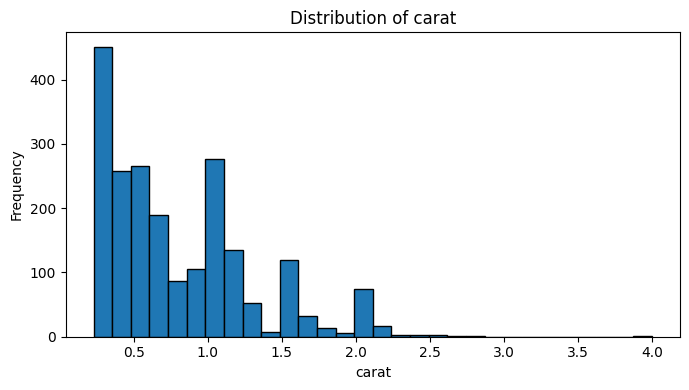

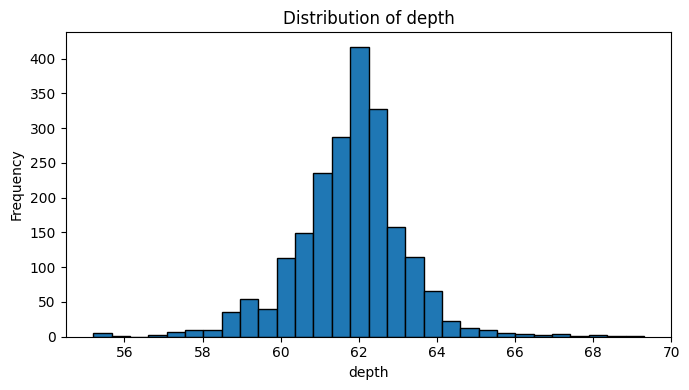

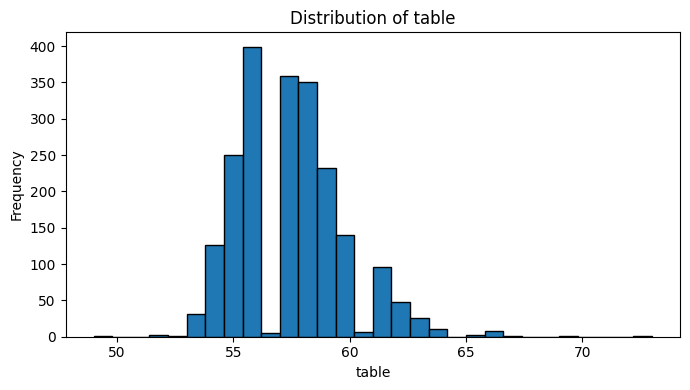

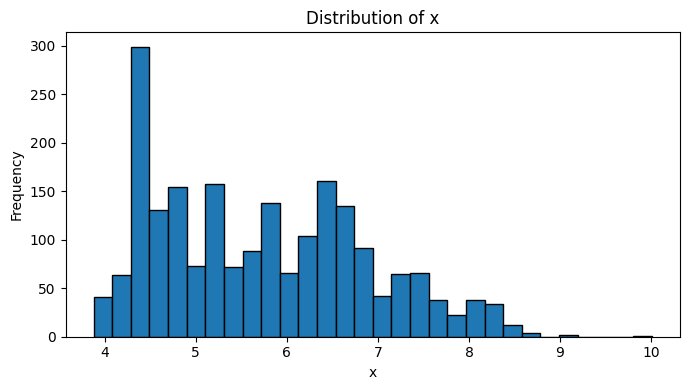

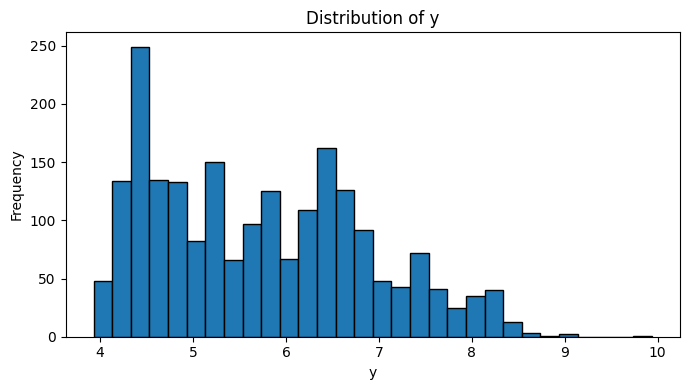

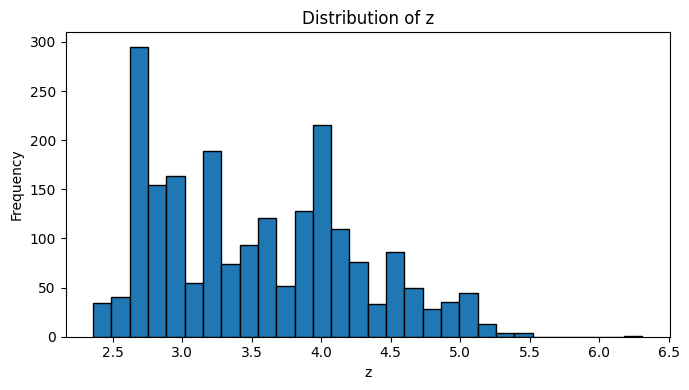

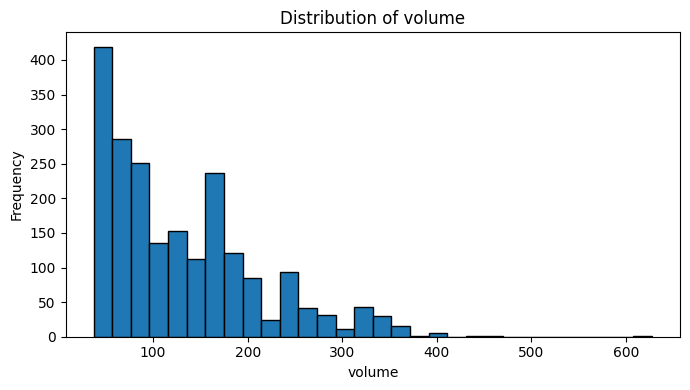

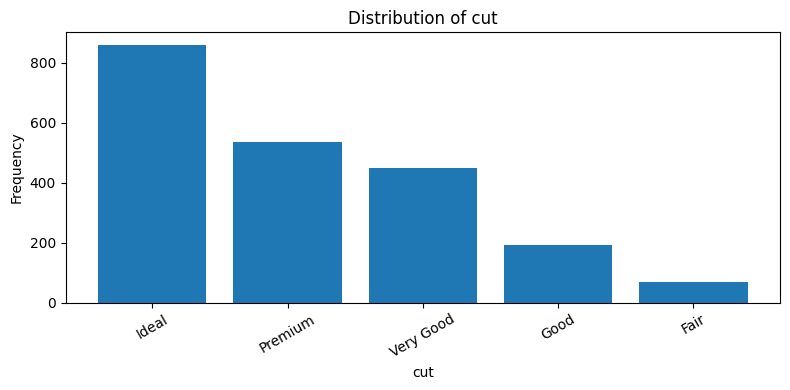

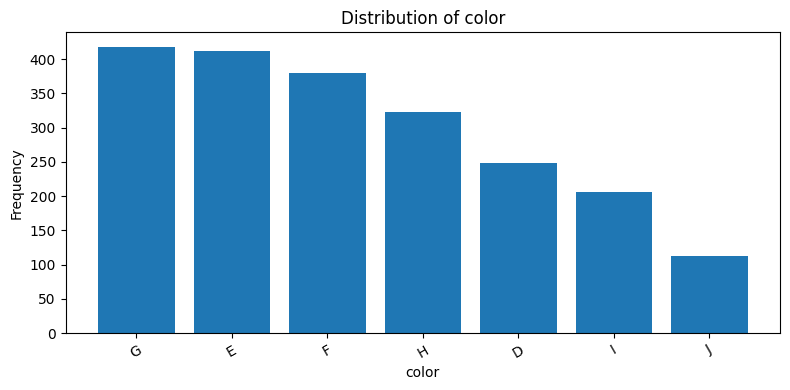

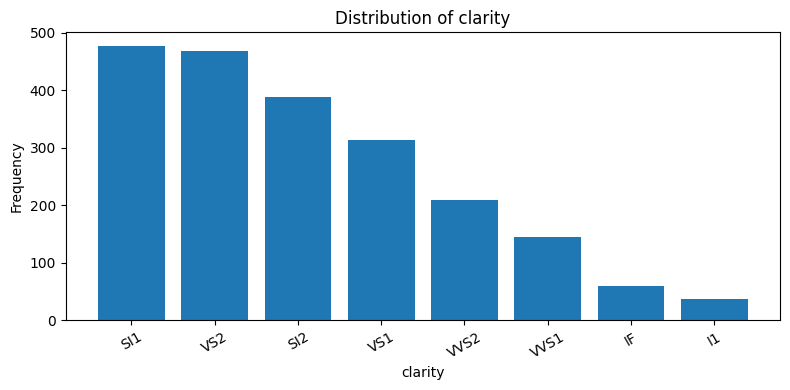

In [23]:
numeric_features = [c for c in df_clean.select_dtypes(include=np.number).columns if c != TARGET]
categorical_features = df_clean.select_dtypes(include="object").columns.tolist()

for col in numeric_features:
    plt.figure(figsize=(7, 4))
    plt.hist(df_clean[col].dropna(), bins=30, edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

for col in categorical_features:
    counts = df_clean[col].value_counts()
    plt.figure(figsize=(8, 4))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

### A3 observation — student interpretation required

Write observations for the feature-distribution plots. Mention notable skew, spread, long tails, or category-frequency differences you can actually see.

### 4.2 Correlation heatmap

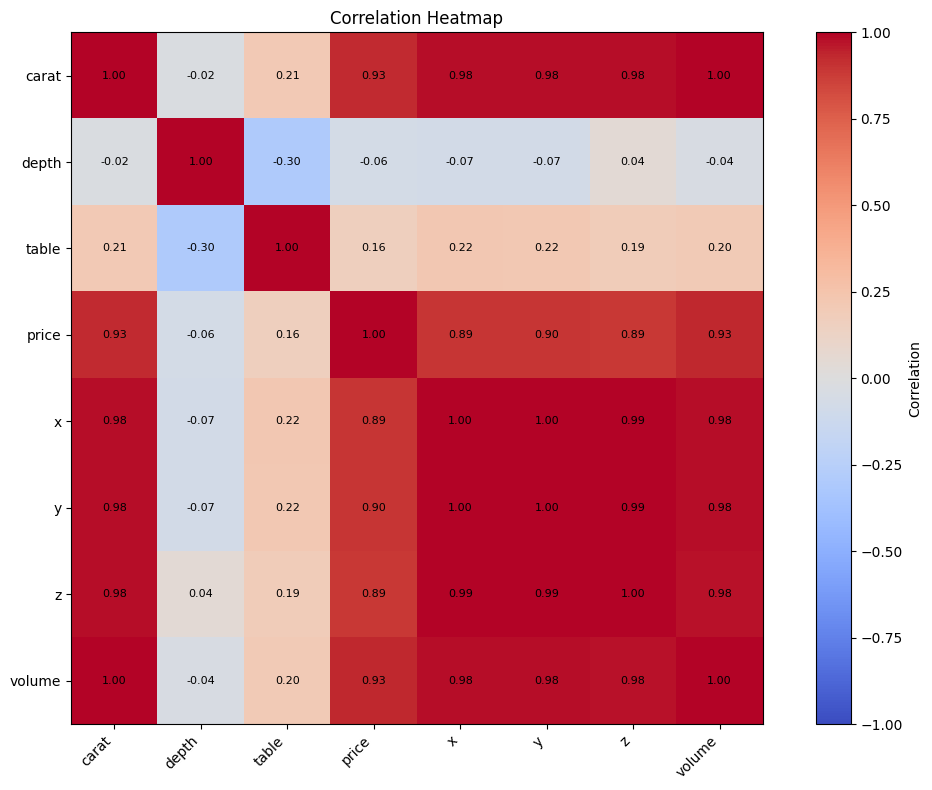

Correlations with price:


,correlation
price,1.000000
volume,0.931300
carat,0.929040
y,0.896134
x,0.893700
z,0.888481
table,0.161579
depth,-0.063104


In [24]:
corr = df_clean.select_dtypes(include=np.number).corr()
fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Correlation Heatmap")

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.tight_layout()
plt.show()

print("Correlations with price:")
display(corr[TARGET].sort_values(ascending=False).to_frame("correlation"))

### A3 observation — student interpretation required

Use the displayed correlations to identify the strongest relationships with `price` and any potential multicollinearity among the physical dimensions. Do not claim causation from correlation alone.

### 4.3 Target distribution

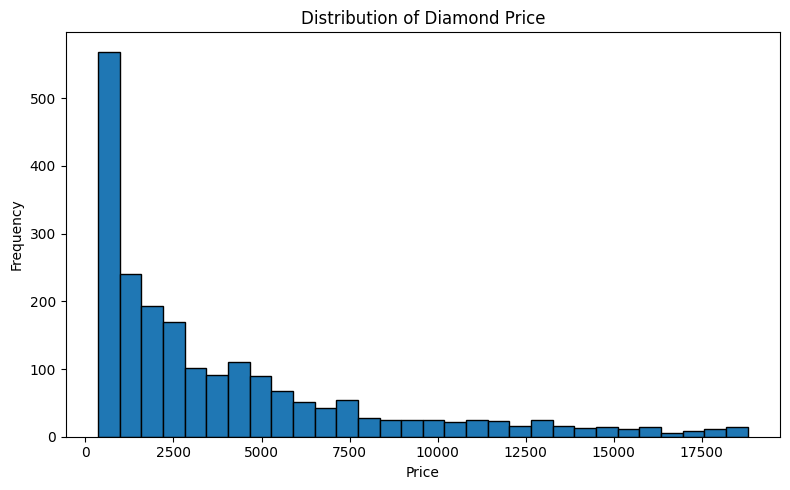

Mean price: 3969.03
Median price: 2322.00
Skewness: 1.6115


In [25]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean[TARGET], bins=30, edgecolor="black")
plt.title("Distribution of Diamond Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print(f"Mean price: {df_clean[TARGET].mean():.2f}")
print(f"Median price: {df_clean[TARGET].median():.2f}")
print(f"Skewness: {df_clean[TARGET].skew():.4f}")

### A3 observation — student interpretation required

Describe the shape of the price distribution and relate the mean/median/skewness values to what you see in the plot.

### 4.4 Feature-target relationships — at least two required

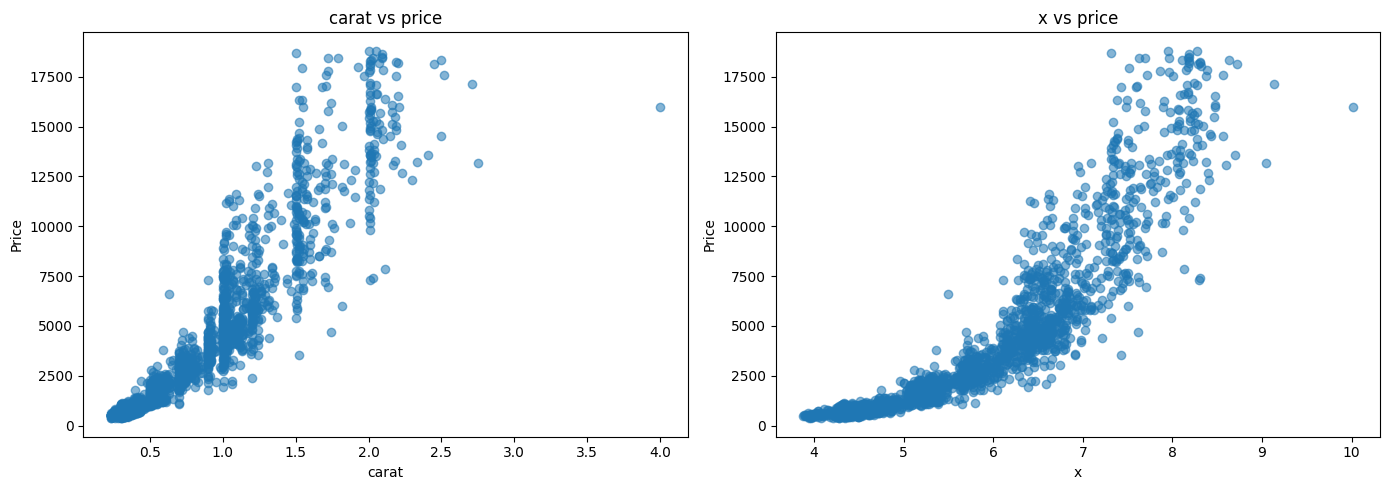

In [26]:
plot_features = ["carat", "x"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feature in zip(axes, plot_features):
    ax.scatter(df_clean[feature], df_clean[TARGET], alpha=0.55)
    ax.set_title(f"{feature} vs {TARGET}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Price")
plt.tight_layout()
plt.show()

### A3 observation — student interpretation required

Explain the visible relationship for each of the two feature-target plots: direction, approximate linearity/nonlinearity, spread, and any visible extreme points.

## 5. Train/test split & leakage-safe preprocessing — B2

In [27]:
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

all_numeric = X.select_dtypes(include=np.number).columns.tolist()
all_categorical = X.select_dtypes(include="object").columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("iqr_clip", IQRClipper()),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, all_numeric),
    ("cat", categorical_transformer, all_categorical)
])

print("Numeric features:", all_numeric)
print("Categorical features:", all_categorical)

Train shape: (1679, 10)
Test shape: (420, 10)
Numeric features: ['carat', 'depth', 'table', 'x', 'y', 'z', 'volume']
Categorical features: ['cut', 'color', 'clarity']


### B2 note

The preprocessing is inside the modeling `Pipeline`. This means imputation, IQR clipping, scaling and one-hot encoding are fitted within each training split, preventing information from the test set from leaking into the model.

## 6. Model training — Polynomial Regression

Polynomial Regression is implemented as `PolynomialFeatures` followed by Linear Regression. We begin with degree 2, then compare degrees 1, 2 and 3 using cross-validation on the training set.

In [28]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("linear", LinearRegression())
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"Degree-2 Test R²:   {r2:.4f}")
print(f"Degree-2 Test RMSE: {rmse:.4f}")
print(f"Degree-2 Test MAE:  {mae:.4f}")

Degree-2 Test R²:   0.9683
Degree-2 Test RMSE: 739.6388
Degree-2 Test MAE:  461.9328


## 7. 5-fold cross-validated R²

In [29]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
# CV for the baseline degree-2 polynomial model on the full dataset.
# Each fold fits the preprocessing steps on its training portion only.
degree2_cv_scores = cross_val_score(model, X, y, cv=cv, scoring="r2", n_jobs=1)
print("Baseline degree-2 5-fold CV R² scores:", np.round(degree2_cv_scores, 4))
print(f"Baseline degree-2 mean CV R²: {degree2_cv_scores.mean():.4f}")
print(f"Baseline degree-2 CV R² std:  {degree2_cv_scores.std():.4f}")
print(f"Held-out test R²: {r2:.4f}")


Baseline degree-2 5-fold CV R² scores: [0.9683 0.9622 0.9743 0.9623 0.922 ]
Baseline degree-2 mean CV R²: 0.9578
Baseline degree-2 CV R² std:  0.0185
Held-out test R²: 0.9683


### CV observation — student interpretation required

Compare the mean 5-fold CV R² with the held-out test R². Discuss whether the values are reasonably close and what that suggests about generalisation.

## 8. Polynomial degree comparison

In [30]:
degree_results = []
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for degree in [1, 2, 3]:
    candidate = Pipeline([
        ("preprocessor", preprocessor),
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("linear", LinearRegression())
    ])
    degree_cv_scores = cross_val_score(candidate, X_train, y_train, cv=cv, scoring="r2", n_jobs=1)
    candidate.fit(X_train, y_train)
    pred = candidate.predict(X_test)
    degree_results.append({
        "Degree": degree,
        "Mean CV R²": degree_cv_scores.mean(),
        "Test R²": r2_score(y_test, pred),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "Test MAE": mean_absolute_error(y_test, pred)
    })

degree_df = pd.DataFrame(degree_results).sort_values("Mean CV R²", ascending=False).reset_index(drop=True)
display(degree_df)

best_degree = int(degree_df.iloc[0]["Degree"])
best_poly_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("poly", PolynomialFeatures(degree=best_degree, include_bias=False)),
    ("linear", LinearRegression())
])
best_poly_pipeline.fit(X_train, y_train)
best_poly_pred = best_poly_pipeline.predict(X_test)

print("Selected degree from training-only 5-fold CV:", best_degree)
print(f"Selected degree test R²: {r2_score(y_test, best_poly_pred):.4f}")

,Degree,Mean CV R²,Test R²,Test RMSE,Test MAE
0,1,0.933999,0.935669,1054.089447,678.685116
1,2,0.895748,0.968326,739.638849,461.932771
2,3,-34393.966277,-1408.074278,156003.627235,19138.131886


Selected degree from training-only 5-fold CV: 1
Selected degree test R²: 0.9357


### Algorithm-specific observation — Polynomial degree

Compare the cross-validated R² across degrees 1–3 and describe the trade-off you observe between model flexibility and generalisation. The selected degree is based on training-set cross-validation, not the test set.

## 9. Diagnostic visualisations — C4 contribution

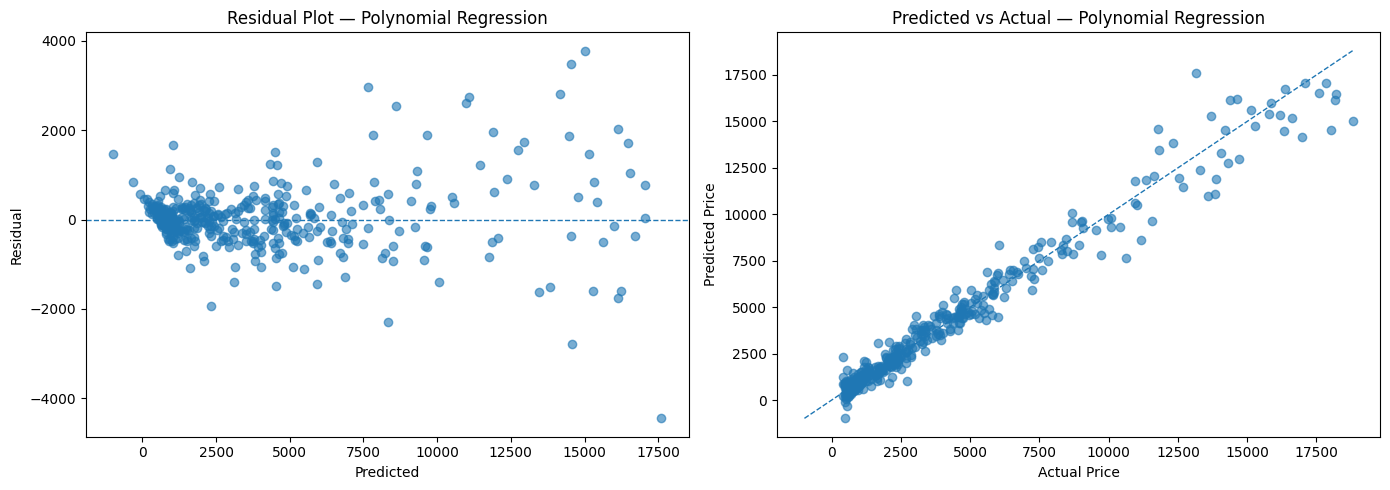

In [31]:
diagnostic_pred = y_pred
residuals = y_test - diagnostic_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(diagnostic_pred, residuals, alpha=0.6)
axes[0].axhline(0, linestyle="--", linewidth=1)
axes[0].set_title("Residual Plot — Polynomial Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residual")

axes[1].scatter(y_test, diagnostic_pred, alpha=0.6)
lims = [min(y_test.min(), diagnostic_pred.min()), max(y_test.max(), diagnostic_pred.max())]
axes[1].plot(lims, lims, linestyle="--", linewidth=1)
axes[1].set_title("Predicted vs Actual — Polynomial Regression")
axes[1].set_xlabel("Actual Price")
axes[1].set_ylabel("Predicted Price")

plt.tight_layout()
plt.show()

### Diagnostic observation — student interpretation required

Use the residual plot to comment on whether residuals are centered around zero and whether you see systematic structure. Use the predicted-vs-actual plot to comment on how closely predictions follow the diagonal.

## 10. Save model and a machine-readable result row

In [32]:
# Resolve the project root for both the GitHub layout and this execution environment.
if Path("../data").exists():
    PROJECT_ROOT = Path("..")
elif Path("data").exists():
    PROJECT_ROOT = Path(".")
elif Path("/mnt/data/data").exists():
    PROJECT_ROOT = Path("/mnt/data")
else:
    PROJECT_ROOT = Path("/mnt/data") if Path("/mnt/data/diamonds_sampled.csv").exists() else Path(".")

RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Save the baseline pipeline for this algorithm.
joblib.dump(pipeline if "pipeline" in globals() else model, MODELS_DIR / "polynomial_regression_baseline.joblib")

result_row = pd.DataFrame([{
    "Model": "Polynomial Regression",
    "R2": r2,
    "RMSE": rmse,
    "MAE": mae,
    "CV_R2_Mean": degree2_cv_scores.mean(),
    "CV_R2_Std": degree2_cv_scores.std()
}])
result_row.to_csv(RESULTS_DIR / "regression_polynomial_results.csv", index=False)
display(result_row)


,Model,R2,RMSE,MAE,CV_R2_Mean,CV_R2_Std
0,Polynomial Regression,0.968326,739.638849,461.932771,0.957828,0.018483
